# Scenario 5 – SMOTE
**Roll Number:** 24BAD002  
**Name:** Abhishek J


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, precision_recall_curve,
                              average_precision_score, confusion_matrix)
from imblearn.over_sampling import SMOTE

print(f"Roll Number: 24BAD002")
print(f"Name: Abhishek J")


Roll Number: 24BAD002
Name: Abhishek J


## 1. Load Dataset & Check Class Imbalance

In [2]:
df = pd.read_csv("fraud_smote.csv")
print("Shape:", df.shape)
print(df.head())
print("\nClass Distribution (Before SMOTE):")
print(df['Fraud'].value_counts())
print(f"Fraud ratio: {df['Fraud'].mean()*100:.1f}%")


Shape: (120, 5)
    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0

Class Distribution (Before SMOTE):
Fraud
0    110
1     10
Name: count, dtype: int64
Fraud ratio: 8.3%


## 2. Split Features

In [3]:
X = df.drop('Fraud', axis=1)
y = df['Fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print("Train class dist:", y_train.value_counts().to_dict())


Train: 96, Test: 24
Train class dist: {0: 88, 1: 8}


## 3. Train Model BEFORE SMOTE

In [4]:
clf_before = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_before.fit(X_train, y_train)
pred_before = clf_before.predict(X_test)
prob_before = clf_before.predict_proba(X_test)[:, 1]

print("Before SMOTE:")
print(classification_report(y_test, pred_before, target_names=['Normal', 'Fraud']))


Before SMOTE:
              precision    recall  f1-score   support

      Normal       0.92      1.00      0.96        22
       Fraud       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



## 4. Apply SMOTE

In [5]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE – Train class dist:", pd.Series(y_train_sm).value_counts().to_dict())
print(f"Resampled train size: {X_train_sm.shape[0]}")


After SMOTE – Train class dist: {1: 88, 0: 88}
Resampled train size: 176


## 5. Train Model AFTER SMOTE

In [6]:
clf_after = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_after.fit(X_train_sm, y_train_sm)
pred_after = clf_after.predict(X_test)
prob_after = clf_after.predict_proba(X_test)[:, 1]

print("After SMOTE:")
print(classification_report(y_test, pred_after, target_names=['Normal', 'Fraud']))


After SMOTE:
              precision    recall  f1-score   support

      Normal       0.91      0.91      0.91        22
       Fraud       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



## 6. Visualization – Class Distribution & Precision-Recall Curve

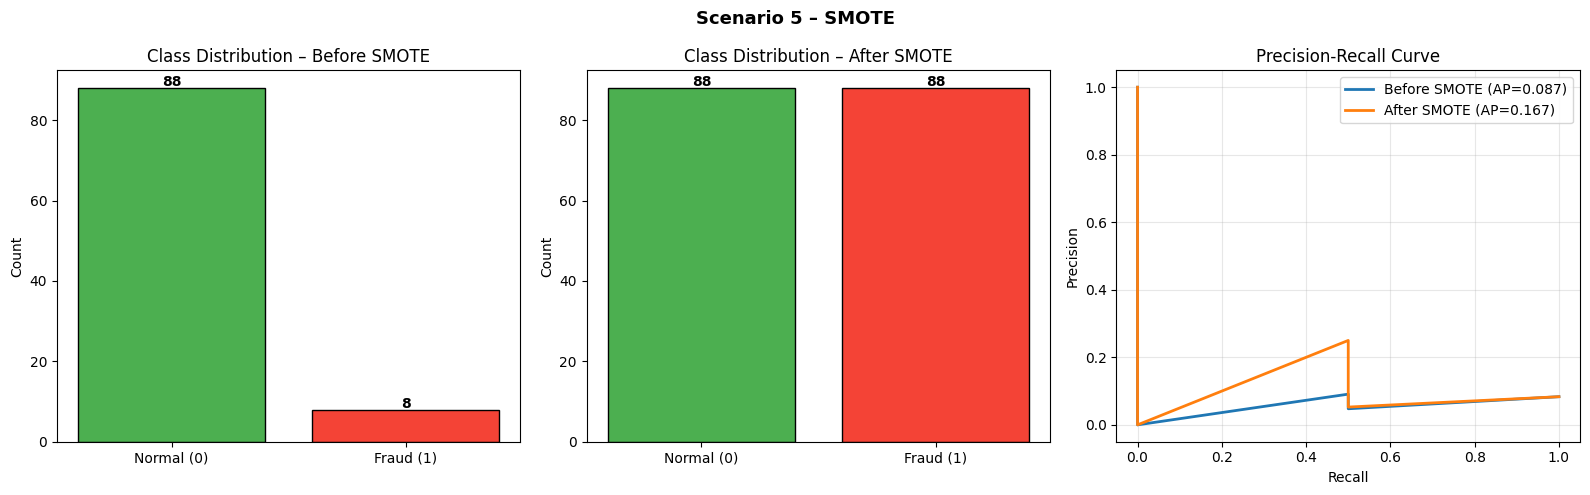

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Scenario 5 – SMOTE", fontsize=13, fontweight='bold')

# Before SMOTE distribution
before_counts = y_train.value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], before_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title("Class Distribution – Before SMOTE")
axes[0].set_ylabel("Count")
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# After SMOTE distribution
after_counts = pd.Series(y_train_sm).value_counts().sort_index()
axes[1].bar(['Normal (0)', 'Fraud (1)'], after_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black')
axes[1].set_title("Class Distribution – After SMOTE")
axes[1].set_ylabel("Count")
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Precision-Recall Curve
for label, prob in [("Before SMOTE", prob_before), ("After SMOTE", prob_after)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[2].plot(rec, prec, lw=2, label=f"{label} (AP={ap:.3f})")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scenario5_output.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")


## Summary

In [8]:
from sklearn.metrics import recall_score, precision_score
rec_before = recall_score(y_test, pred_before, zero_division=0)
rec_after  = recall_score(y_test, pred_after,  zero_division=0)

print(f"  Fraud % in raw data  : {y.mean()*100:.1f}%")
print(f"  Recall Before SMOTE  : {rec_before:.4f}")
print(f"  Recall After SMOTE   : {rec_after:.4f}")
print(f"  Recall Improvement   : {rec_after - rec_before:+.4f}")



  Fraud % in raw data  : 8.3%
  Recall Before SMOTE  : 0.0000
  Recall After SMOTE   : 0.0000
  Recall Improvement   : +0.0000
